# 001 - MA Crossover Optimization
 

  
  
♾️ Summary, commentary on key topics, analysis of main concepts and takeaways  
‼️ Limitations, threats, and warnings concerning data accuracy, backtest reliability, or other biases/fallacies    
🔆 Leading suggestions and refinements, ways to improve code or robustness of the strategy  

 

     
      
  

[MoneyforNotn](https://github.com/MoneyforNotn)

Python version: [3.11.9](https://www.python.org/downloads/)


# **Understanding Moving Averages**

Moving Averages of asset prices help traders determine what is happening in the market by smoothing out price data and filtering out short-term volatility. MAs therefore are used as an  `Market Trend Indicator`

Many traders use moving averages as the basis for a trend-following trading system as a confirmation signal to another indicator
>Although possible to create entry signals only based on MA/price or MA/MA crossovers, more robust trading systems use moving averages only as a one of its condition parameters for entry (ex. to enter long position price must be trading above 200-EMA)

MA crossover trading strategies are generally considered **Momentum** systems - they capitalize on the continuation of existing trends. On the contrary, **Mean Reversion** systems bet on prices returning to their mean (average) after deviating  

#### *Could one indicator serve as signal for both directions?*
Yes. That is why simple indicator strategies rarely outperform the market and why many robust strategies rely on multiple combinations of signals

#### Theory behind MA systems
<div class="alert alert-block alert-info">
<b>♾️</b> THEORY - Although simple, MA crossover strategies can reduce market risk by providing a 'safety net' during severe market downturns, though this may come at the expense of lower returns relative to the broader market
</div>

### **Long Only**

MA crossover strategies (especially longer-period MAs) are appropriate on 'long-only' trading systems. MAs provide a trend-following framework that seeks to maximize gains during bull phases while reducing risk during bear markets

**While both-way crossover strategies can work on certain assets, this system bases its logic on the assumption that stock prices go up over time** 

##### Data universe - **S&P 500**, (GSPC/SPX), OHLCV, Range: 01/03/1995-12/31/2024 (30 years)

## **Backtesting Systems**

***1.1 - Numerical backtest***  
`NumPy` - (python arrays/matrices) Calculating Performance Metrics using vectorized operations on large arrays  
Plot daily returns, benchmark drawdowns, strategy performance

***1.2 - Backtesting.py***  
[Backtesting.py](https://kernc.github.io/backtesting.py/) open-source Python framework for backtesting, optimizing & plotting  
`.lib` - functions and strategy classes for reuse, `.test` - data and utilities for testing









### *CREDITS*

Historical price data from [stooq.com](https://stooq.com/)

Inspired by code originally published by russs123.
 * [See original code](https://github.com/russs123/moving_average/blob/main/README.md) *full license attached beneath*

***  
 ## ***1.1 - Numerical backtest***
***

## Libraries 

*Yahoo Finance* - historical price data   

In [ ]:
%pip install seaborn

^C
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
#  Historical prices, data storing & transforming  libraries
import yfinance as yf  
import pandas as pd
import numpy as np  
import datetime
# Statistical data visualization, built on matplotlib
import matplotlib.pyplot as plt
import seaborn as sns  

## Data preparation and visualization 

Before strategy formulation or formal backtesting plotting raw data is essential for **verifying data quality** and visualization

Short-term trend ... 50 period MA  
Long-term trend ... 200 period MA

In [ ]:
FAST_MA = 50  # Fast moving average period
SLOW_MA = 200  # Slow moving average period
STARTING_BALANCE = 10000

# Define time period
START = datetime.datetime(1995, 1, 1) 
END = datetime.datetime(2025, 1, 1) 
YEARS = (END - START).days / 365.25  # Total years for the backtest, accounting for leap years

# Define the financial instrument (S&P 500 index), load data into a pandas dataframe 'price'
symbol = "^GSPC"
price = yf.download(symbol, start=START, end=END)

# Display first five rows of the data to check structure
price.head()

C:\Users\user\AppData\Local\Temp\ipykernel_20740\1792891162.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price = yf.download(symbol, start=START, end=END)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
1995-01-03,459.109985,459.269989,457.200012,459.209991,262450000
1995-01-04,460.709991,460.720001,457.559998,459.130005,319510000
1995-01-05,460.339996,461.299988,459.750000,460.730011,309050000
1995-01-06,460.679993,462.489990,459.470001,460.380005,308070000
1995-01-09,460.829987,461.769989,459.739990,460.670013,278790000


This trading system only uses Close and Open data (and date)

Good practice to leave code below in seperate code window...running twice returns an error

In [ ]:
# Drop redundant columns
price = price.drop(['High', 'Low', 'Volume'], axis=1)

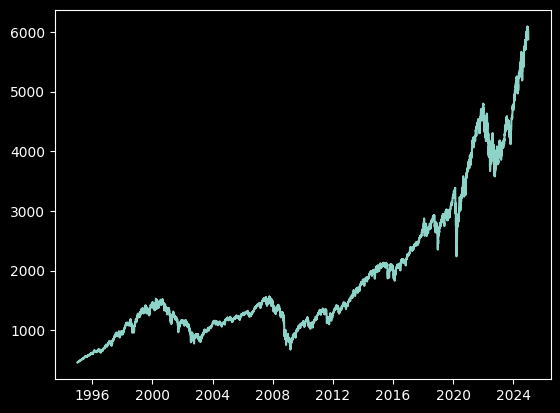

In [ ]:
# Plot chart
plt.style.use('dark_background')
plt.plot(price.Close)
plt.show()

## Calculating benchmark returns & drawdowns

The benchmark represents a buy-and-hold strategy, providing a baseline to evaluate the active moving average strategy  
Price-only indexes such as S&P 500 (without reinvested dividends) has historically averaged around 8% annually, with no fees and costs

<div class="alert alert-block alert-danger">
<b>‼️</b> At this point, we assume no fees deducted or transaction costs. Real-world trading is not without friction, as it involves slippage, commissions, and other trading fees - especially on lower timeframes where signals occur more frequently
</div>  

**1.2 - Backtesting.py** - alternative backtesting method with commissions 


<div class="alert alert-block alert-danger">
<b>‼️</b> Note that this numeric backtest calculates strategy balance on every days' returns. Reinvestment strategies will generally have higher returns than same strategy which does not reinvest (again, assuming no costs). This may portray some systems as more favorable than they are
</div>




`price['Return']` computes the daily return by dividing yesterday's close by today's close   
`price[Bench_Bal']` balance growth on daily returns, serving as a benchmark for strategy returns   
`price['Bench_DD']` calculate drawdown by subtracting peak from current balance   
`bench_dd` find maximum percentage decline from the peak balance  

In [ ]:
price['Return'] = price.Close / price.Close.shift(1)

price['Bench_Bal'] = STARTING_BALANCE * price.Return.cumprod()

price['Bench_Peak'] = price.Bench_Bal.cummax()

price['Bench_DD'] = price.Bench_Bal - price.Bench_Peak

bench_dd = round((((price.Bench_DD / price.Bench_Peak).min()) * 100), 2)

price.tail()

Price,Close,Open,Return,Bench_Bal,Bench_Peak,Bench_DD
Ticker,^GSPC,^GSPC,,,,
Date,,,,,,
2024-12-24,6040.040039,5984.629883,1.011043,131559.761969,132653.834895,-1094.072925
2024-12-26,6037.589844,6024.970215,0.999594,131506.393596,132653.834895,-1147.441299
2024-12-27,5970.839844,6006.169922,0.988944,130052.493613,132653.834895,-2601.341282
2024-12-30,5906.939941,5920.669922,0.989298,128660.672385,132653.834895,-3993.162510
2024-12-31,5881.629883,5919.740234,0.995715,128109.387085,132653.834895,-4544.447809


## Moving averages and visualization

`.rolling(window=` creates a rolling window (a subset of data) by averaging 50 and 200 past closing prices

In [ ]:
#calculate moving averages
price['Fast_MA'] = price.Close.rolling(window = FAST_MA).mean()
price['Slow_MA'] = price.Close.rolling(window = SLOW_MA).mean()

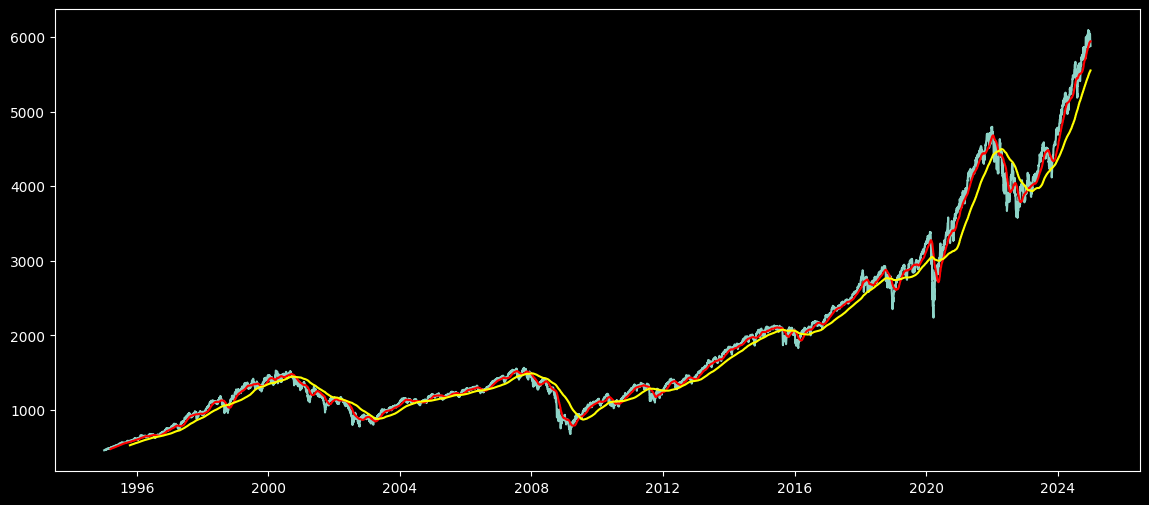

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(price.Close)
plt.plot(price.Fast_MA, color="red")
plt.plot(price.Slow_MA, color="yellow")

plt.show()

## Defining entry signals

If short-term MA crosses above (or is currenlty above) long-term MA, new bullish trend is signaled and a long position is entered  

Alternatively, if short-term MA < long-term MA, position is exited and strategy will remain uninvolved until trend changes

Crossovers can generate many *false* signals during sideways markets. Relying solely on MAs may not be profitable across assets which do not trend



`price['Long']` simple boolean condition - acts as signal for when the system should be in a long position

In [ ]:
price['Long'] = price.Fast_MA > price.Slow_MA

price.tail()

Price,Close,Open,Return,Bench_Bal,Bench_Peak,Bench_DD,Fast_MA,Slow_MA,Long
Ticker,^GSPC,^GSPC,,,,,,,
Date,,,,,,,,,
2024-12-24,6040.040039,5984.629883,1.011043,131559.761969,132653.834895,-1094.072925,5933.808203,5535.671353,True
2024-12-26,6037.589844,6024.970215,0.999594,131506.393596,132653.834895,-1147.441299,5938.254805,5539.982952,True
2024-12-27,5970.839844,6006.169922,0.988944,130052.493613,132653.834895,-2601.341282,5940.822197,5544.010601,True
2024-12-30,5906.939941,5920.669922,0.989298,128660.672385,132653.834895,-3993.162510,5942.131592,5547.792900,True
2024-12-31,5881.629883,5919.740234,0.995715,128109.387085,132653.834895,-4544.447809,5942.470791,5551.615601,True


`price['Sys_Ret']` if the previous day's signal was *True* (long position) then the system gains today's return

In [ ]:
# Calculate daily returns
price['Sys_Ret'] = np.where(price.Long.shift(1) == True, price.Return, 1)

# Calculate system balance
price['Sys_Bal'] = STARTING_BALANCE * price.Sys_Ret.cumprod()
price.tail()

Price,Close,Open,Return,Bench_Bal,Bench_Peak,Bench_DD,Fast_MA,Slow_MA,Long,Sys_Ret,Sys_Bal
Ticker,^GSPC,^GSPC,,,,,,,,,
Date,,,,,,,,,,,
2024-12-24,6040.040039,5984.629883,1.011043,131559.761969,132653.834895,-1094.072925,5933.808203,5535.671353,True,1.011043,108591.096247
2024-12-26,6037.589844,6024.970215,0.999594,131506.393596,132653.834895,-1147.441299,5938.254805,5539.982952,True,0.999594,108547.045314
2024-12-27,5970.839844,6006.169922,0.988944,130052.493613,132653.834895,-2601.341282,5940.822197,5544.010601,True,0.988944,107346.977827
2024-12-30,5906.939941,5920.669922,0.989298,128660.672385,132653.834895,-3993.162510,5942.131592,5547.792900,True,0.989298,106198.150931
2024-12-31,5881.629883,5919.740234,0.995715,128109.387085,132653.834895,-4544.447809,5942.470791,5551.615601,True,0.995715,105743.113052


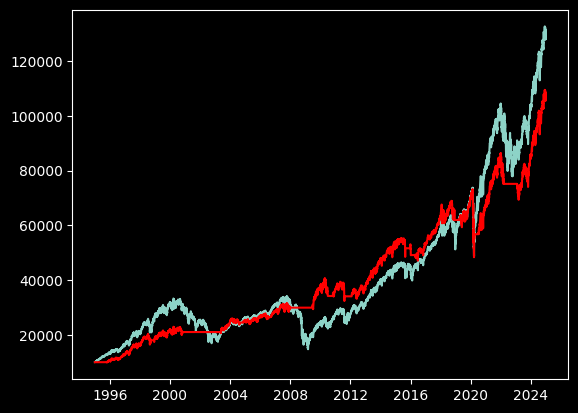

In [ ]:
plt.plot(price.Bench_Bal,)
plt.plot(price.Sys_Bal, color="red")

plt.show()

In [ ]:
# Calculate drawdown
price['Sys_Peak'] = price.Sys_Bal.cummax()

price['Sys_DD'] = price.Sys_Bal - price.Sys_Peak

sys_dd = round((((price.Sys_DD / price.Sys_Peak).min()) * 100), 2)

print(sys_dd)

-33.92


### Calculate performanc metrics and compare against a benchmark

In [ ]:
bench_return = round(((price.Bench_Bal.iloc[-1]/price.Bench_Bal.iloc[1]) - 1) * 100, 2)
bench_cagr = round(((((price.Bench_Bal.iloc[-1]/price.Bench_Bal.iloc[1])**(1/YEARS))-1)*100), 2)
sys_return = round(((price.Sys_Bal.iloc[-1]/price.Sys_Bal.iloc[0]) - 1) * 100, 2)
sys_cagr = round(((((price.Sys_Bal.iloc[-1]/price.Sys_Bal.iloc[0])**(1/YEARS))-1)*100), 2)
sys_tim = round((price.Long.sum() / price.shape[0]) * 100, 2)

print(f'Benchmark Total return: {bench_return}%')
print(f'Benchmark CAGR: {bench_cagr}%')
print(f'Benchmark DD: {bench_dd}%')
print('')
print(f'System Total return: {sys_return}%')
print(f'System CAGR: {sys_cagr}%')
print(f'System DD: {sys_dd}%')
print(f'System Time in the Market: {sys_tim}%')

Benchmark Total return: 1176.64%
Benchmark CAGR: 8.86%
Benchmark DD: -56.78%

System Total return: 957.43%
System CAGR: 8.18%
System DD: -33.92%
System Time in the Market: 72.52%


In this backtest, MA crossover strategy has managed to cut risk by almost 50% while averaging only slightly lower annual growth rate. The system deemed the market to be in a downtrend and was uninvolved ~27.5% of the time

As further explored in **1.2**, MA crossover systems appear to reduce drawdowns while remaining decently profitable  
*Performance metrics and backtesting statistics can be easily accessed via specific python libraries such as [Backtesting.py](https://kernc.github.io/backtesting.py/)*


***  
 ## ***1.2 - Backtesting.py***
***

Effective method for running a series of backtests over all defined combinations of fast and slow MA periods to find the best-performing systems, measured by CAGR, or an other chosen parameter

## Libraries 

[Backtesting.py](https://kernc.github.io/backtesting.py/) open-source Python framework for backtesting, optimizing & plotting  

`backtest.optimize` - optimize strategy parameters to an optimal combination



In [ ]:
%pip install backtesting

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
from backtesting import Backtest, Strategy
from backtesting.test import SMA
from backtesting.lib import crossover

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\backtesting\_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

## Data preparation

In [ ]:
df=pd.read_csv("^spx_1d.csv")
print(df.columns)
df

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


,Date,Open,High,Low,Close,Volume
0,1995-01-03,459.21,459.27,457.20,459.11,1.458056e+08
1,1995-01-04,459.13,460.72,457.56,460.71,1.775056e+08
2,1995-01-05,460.73,461.30,459.75,460.34,1.716944e+08
3,1995-01-06,460.38,462.49,459.47,460.68,1.711500e+08
4,1995-01-09,460.67,461.77,459.74,460.83,1.548833e+08
...,...,...,...,...,...,...
7547,2024-12-24,5984.63,6040.10,5981.44,6040.04,1.133217e+09
7548,2024-12-26,6024.97,6049.75,6007.37,6037.59,1.506251e+09
7549,2024-12-27,6006.17,6006.17,5932.95,5970.84,1.817798e+09
7550,2024-12-30,5920.67,5940.79,5869.16,5906.94,1.943393e+09


Ensuring date is a *datetime* object is necessary for this backtesting library

In [ ]:

df["Date"] = pd.to_datetime(df["Date"], format='%Y-%m-%d', errors='coerce')
df.set_index("Date",inplace=True)
df=df[df.High!=df.Low] #discarting days where low=high (no movement)
len(df)
df

,Open,High,Low,Close,Volume
Date,,,,,
1995-01-03,459.21,459.27,457.20,459.11,1.458056e+08
1995-01-04,459.13,460.72,457.56,460.71,1.775056e+08
1995-01-05,460.73,461.30,459.75,460.34,1.716944e+08
1995-01-06,460.38,462.49,459.47,460.68,1.711500e+08
1995-01-09,460.67,461.77,459.74,460.83,1.548833e+08
...,...,...,...,...,...
2024-12-24,5984.63,6040.10,5981.44,6040.04,1.133217e+09
2024-12-26,6024.97,6049.75,6007.37,6037.59,1.506251e+09
2024-12-27,6006.17,6006.17,5932.95,5970.84,1.817798e+09


Define MA crossover strategy with same parameters as previously (long-only)  
`init()` method runs once at the start of the backtest  
`next()` step only checks whether these arrays cross over

In [ ]:
class Sma4Cross(Strategy):
    n1 = 50
    n2 = 200
    
    def init(self):
        self.sma_fast = self.I(SMA, self.data.Close, self.n1)
        self.sma_slow = self.I(SMA, self.data.Close, self.n2)
        
    def next(self):
        if not self.position:
            # Enter long if fast MA crosses above slow MA
            if crossover(self.sma_fast, self.sma_slow):
                self.buy()
        
        else:
            # Exit position if fast MA crosses below slow MA
            if crossover(self.sma_slow, self.sma_fast):
                self.position.close()

## Backtest

By default, the backtest.py does not automatically close open positions at the end of the testing period    

If `finalize_trades=True`, the trades that are still active and ongoing at the end of the backtest will be closed on the last bar and will contribute to the computed backtest statistics 
 
Using `commission=.01` to simulate 1% transaction fees upon entering and exiting trades

In [ ]:
%%time
# See run time
backtest = Backtest(df, Sma4Cross, commission=.01, finalize_trades=True)

stats = backtest.run() # Run the backtest
stats

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

CPU times: total: 141 ms
Wall time: 161 ms


Start                     1995-01-03 00:00:00
End                       2024-12-31 00:00:00
Duration                  10955 days 00:00:00
Exposure Time [%]                    62.79131
Equity Final [$]                   43094.7968
Equity Peak [$]                    44702.8886
Commissions [$]                     4801.1032
Return [%]                          330.94797
Buy & Hold Return [%]               908.80401
Return (Ann.) [%]                     4.99531
Volatility (Ann.) [%]                12.48471
CAGR [%]                              3.41744
Sharpe Ratio                          0.40011
Sortino Ratio                         0.58623
Calmar Ratio                          0.15343
Alpha [%]                           -42.21268
Beta                                  0.41061
Max. Drawdown [%]                   -32.55756
Avg. Drawdown [%]                    -2.04299
Max. Drawdown Duration     1319 days 00:00:00
Avg. Drawdown Duration       42 days 00:00:00
# Trades                          

<div class="alert alert-block alert-warning">
<b>🔆</b> Filtering with volume or momentu signals could improve robustness of the system on lower timeframes. Alternatively, test and compare across other indexes - any significant dicrepancy may suggest the trend is weak or not transparent

</div>

## Parameter optimization over a grid

Run a series of backtests over all defined combinations of fast and slow MA periods to find the best-performing systems, measured by 'Return (Ann) [%]', or an other chosen parameter  

Find optimal combination of parameter during the sweep (grid search) with `maximize=`  

`random_state=0` set a fixed integer random seed for reproducible optimization results
`maximize='Return (Ann.) [%]` use annual returns as the unit of measurement

Strategy class `backtest` defines parameters before they are optimized. Trading ruler, commissions, etc. are already set

In [ ]:
stats, heatmap = backtest.optimize(
    n1=range(5, 85, 5),
    n2=range(90, 250, 10),
    constraint=lambda p: p.n1 < p.n2,
    maximize='Return (Ann.) [%]',
    max_tries=300,
    random_state=0,
    return_heatmap=True)

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\backtesting\backtesting.py:1624: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimize()` call behind a `if __name__ == '__main__'` guard. Currently using thread-based paralellism, which might be slightly slower for non-numpy / non-GIL-releasing code. See https://github.com/kernc/backtesting.py/issues/1256
  output = _optimize_grid()


Backtest.optimize:   0%|          | 0/256 [00:00<?, ?it/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

In [ ]:
heatmap # Data preview

n1  n2 
5   90    -0.468992
    100   -0.451076
    110    0.019022
    120    0.696672
    130    0.044102
             ...   
80  200    4.954459
    210    4.635304
    220    4.295746
    230    4.410458
    240    4.436642
Name: Return (Ann.) [%], Length: 256, dtype: float64

**Top 3** parameter combinations with highest annual return 

In [ ]:
heatmap.sort_values().iloc[-3:]

n1  n2 
60  200    5.483976
20  160    5.488414
    180    5.733012
Name: Return (Ann.) [%], dtype: float64

In [ ]:
hm = heatmap.groupby(['n1', 'n2']).mean().unstack()
hm = hm[::-1]
hm

n2,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240
n1,,,,,,,,,,,,,,,,
80,0.696964,1.546437,2.283752,2.245318,3.012011,3.054607,3.184695,3.718214,4.076057,3.410185,4.297576,4.954459,4.635304,4.295746,4.410458,4.436642
75,1.240943,1.624196,1.972359,1.615169,2.603274,3.050655,3.208048,3.260172,3.968686,4.058120,3.982648,4.994243,4.599964,4.883928,4.849237,4.618044
70,1.279186,2.509959,2.447515,1.922882,2.104769,2.903149,3.072660,3.249957,3.998013,4.345208,4.338114,4.632135,4.851561,4.905812,5.089535,5.348772
65,2.509028,2.141240,2.994176,3.792599,2.589810,3.002801,3.224505,3.784156,4.071619,4.508269,4.655022,4.847299,4.930208,5.126453,5.098706,5.344426
60,2.944863,3.274287,3.492004,4.006954,3.459056,3.858722,3.214480,3.342964,3.846688,4.073082,5.121991,5.483976,5.421721,5.303746,5.352291,5.322443
55,3.034657,3.489792,3.986704,3.992893,4.965558,5.129976,3.776167,3.855719,3.815309,3.801975,4.543572,5.152377,5.093928,5.294242,5.381782,5.363415
50,3.042206,3.132269,3.325526,4.050979,4.494026,5.355719,5.120371,5.420837,4.573812,4.302296,4.347265,4.995309,5.104008,5.055547,5.040207,5.477656
45,2.568829,3.145610,3.894676,4.014166,4.833352,4.633090,5.118881,5.450781,4.494845,4.360551,3.910952,4.408770,5.076326,4.985091,5.140422,5.428237
40,1.628238,3.021362,2.711878,3.361537,4.605788,4.686084,4.902203,5.094786,4.089500,3.852146,3.991402,4.516759,4.521784,5.093472,5.014845,5.110958


### `Ann. Return` Active optimization heatmap

In [ ]:
from backtesting.lib import plot_heatmaps
import matplotlib.pyplot as plt

plot_heatmaps(heatmap, agg='mean')

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\backtesting\_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

NameError: name 'heatmap' is not defined

In [ ]:
# Switch rows and columns
hm = hm.T

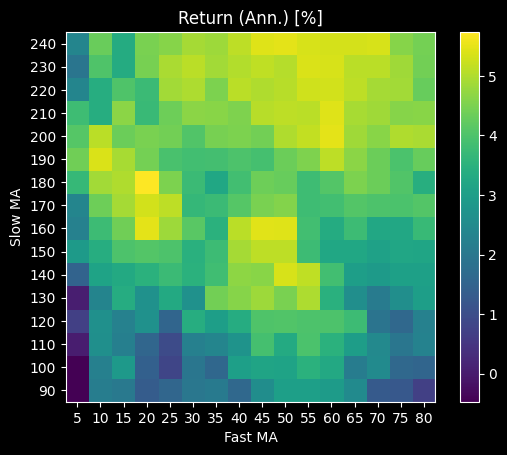

In [ ]:
fig, ax = plt.subplots()

im = ax.imshow(hm, cmap='viridis')

_ = (
    ax.set_xticks(range(len(hm.columns)), labels=hm.columns),
    ax.set_yticks(range(len(hm)), labels=hm.index),
    ax.set_xlabel('Fast MA'),
    ax.set_ylabel('Slow MA'),
    ax.set_title('Return (Ann.) [%]'),
    ax.figure.colorbar(im, ax=ax),
)

# Invert axis
ax.invert_yaxis()

ax.invert_xaxis()

plt.show()

**Maximum drawdown** is an irreplacable metric for analysing strategy risk; measures the largest decline portfilio has suffered

Over past 30 years of data, there is roughly one point in time where the optimization detects max drawdows for every combination - 2008 financial crash  
To avoid this 'bias' optimize for **Average Drawdown %** to compare risk across systems
However, since this metric analyzes a single event for all parameters, this makes the comparison more 'fair' for simulating sudden market downturns

In [ ]:
stats1, heatmap1 = backtest.optimize(
    n1=range(5, 85, 5),
    n2=range(90, 250, 10),
    constraint=lambda p: p.n1 < p.n2,
    maximize='Max. Drawdown [%]',
    max_tries=300,
    random_state=0,
    return_heatmap=True)

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\backtesting\backtesting.py:1624: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimize()` call behind a `if __name__ == '__main__'` guard. Currently using thread-based paralellism, which might be slightly slower for non-numpy / non-GIL-releasing code. See https://github.com/kernc/backtesting.py/issues/1256
  output = _optimize_grid()


Backtest.optimize:   0%|          | 0/256 [00:00<?, ?it/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

In [ ]:
heatmap1.sort_values().iloc[-3:]

heatmap1

hm1 = heatmap1.groupby(['n1', 'n2']).mean().unstack()
hm1 = hm1[::-1]
hm1

n2,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240
n1,,,,,,,,,,,,,,,,
80,-51.403409,-50.949105,-43.629646,-38.115286,-38.032638,-34.700739,-37.443669,-38.089502,-37.158938,-34.646283,-35.091798,-34.787102,-34.865019,-33.596515,-36.084784,-35.137970
75,-43.466518,-46.431513,-50.837953,-35.672217,-33.714033,-33.698038,-33.039974,-35.816801,-35.629845,-36.169520,-35.789122,-36.131442,-35.084760,-35.375751,-35.080969,-35.356792
70,-46.036744,-37.482288,-43.809758,-37.300741,-36.765345,-31.761565,-32.177797,-33.953363,-31.909580,-33.449273,-34.721973,-35.072594,-38.683963,-38.159987,-36.857728,-36.219478
65,-35.587808,-48.040040,-37.675243,-33.923068,-30.807072,-30.344638,-28.942191,-32.008797,-30.554241,-33.130061,-33.209205,-34.501699,-34.953642,-34.039492,-34.512244,-33.736441
60,-35.805685,-37.155890,-39.573623,-33.569325,-30.692524,-32.841217,-33.271283,-31.892951,-30.204746,-31.532744,-31.240917,-33.299005,-31.438909,-31.656275,-33.672114,-31.218651
55,-38.997519,-32.879985,-33.674287,-34.408852,-33.260505,-32.572314,-31.391818,-31.491055,-30.769906,-30.362567,-32.607738,-33.108022,-31.836491,-32.223763,-31.685253,-33.333573
50,-42.905279,-36.615416,-35.559969,-35.026062,-33.839721,-33.565457,-33.330845,-32.718192,-30.358647,-32.255146,-31.509536,-32.557558,-32.566901,-33.093338,-33.150088,-32.725492
45,-47.656710,-38.498544,-28.519126,-34.133332,-31.480882,-32.779074,-35.036947,-32.004526,-33.898206,-31.488582,-33.326115,-30.744207,-31.123240,-33.232589,-32.481322,-31.392754
40,-50.212898,-42.541292,-40.632823,-37.119486,-30.778403,-33.985884,-35.944629,-34.284669,-31.385066,-30.728933,-31.382569,-31.613829,-32.242845,-32.125684,-31.084828,-32.167333


In [ ]:
plot_heatmaps(heatmap1, agg='mean')

GridPlot(id='p1128', ...)

In [ ]:
hm1 = hm1.T

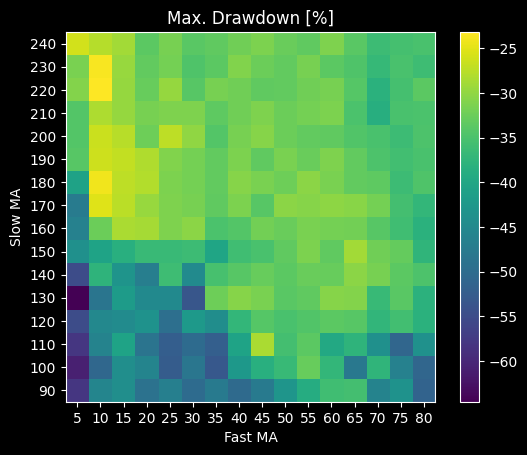

In [ ]:
fig, ax = plt.subplots()
im1 = ax.imshow(hm1, cmap='viridis')
_ = (
    ax.set_xticks(range(len(hm1.columns)), labels=hm1.columns),
    ax.set_yticks(range(len(hm1)), labels=hm1.index),
    ax.set_xlabel('Fast MA'),
    ax.set_ylabel('Slow MA'),
    ax.set_title('Max. Drawdown [%]'),
    ax.figure.colorbar(im1, ax=ax),
)

ax.invert_yaxis()
ax.invert_xaxis()
plt.show()

### Sharpe vs Sortino Ratio

For this study **Sortino Ratio** will be prefered over Sharpe Ratio based on the assumption that indexes tend to trend up and the performence mertric should not suffer from abnormaly profitable trades

* Sharpe measures risk-adjusted return using standard deviation, while Sortino measures risk-adjusted return using only downside risk

In [ ]:
stats2, heatmap2 = backtest.optimize(
    n1=range(5, 85, 5),
    n2=range(90, 250, 10),
    constraint=lambda p: p.n1 < p.n2,
    maximize='Sortino Ratio',
    max_tries=300,
    random_state=0,
    return_heatmap=True)

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\backtesting\backtesting.py:1624: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimize()` call behind a `if __name__ == '__main__'` guard. Currently using thread-based paralellism, which might be slightly slower for non-numpy / non-GIL-releasing code. See https://github.com/kernc/backtesting.py/issues/1256
  output = _optimize_grid()


Backtest.optimize:   0%|          | 0/256 [00:00<?, ?it/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7462 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7452 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7432 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7422 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7412 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7402 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7382 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7362 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7352 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7342 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7332 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7322 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7312 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/7372 [00:00<?, ?bar/s]

In [ ]:
heatmap2.sort_values().iloc[-3:]

heatmap2

hm2 = heatmap2.groupby(['n1', 'n2']).mean().unstack()
hm2 = hm2 [::-1]
hm2


n2,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240
n1,,,,,,,,,,,,,,,,
80,0.081682,0.175230,0.249292,0.267608,0.353322,0.357877,0.372338,0.433865,0.487535,0.409714,0.502423,0.565981,0.537114,0.505228,0.499990,0.505969
75,0.144431,0.179436,0.214374,0.190563,0.306665,0.360563,0.383097,0.385440,0.468189,0.482697,0.467933,0.580709,0.537108,0.557162,0.552675,0.534666
70,0.142219,0.280856,0.271858,0.227888,0.256681,0.349616,0.363112,0.382048,0.477279,0.511603,0.515195,0.547595,0.549744,0.560020,0.596497,0.619886
65,0.286082,0.247021,0.334199,0.422937,0.315706,0.372235,0.397354,0.440270,0.489324,0.526572,0.556660,0.561913,0.577528,0.603241,0.594045,0.628087
60,0.335099,0.367003,0.396721,0.443251,0.426367,0.465845,0.386674,0.404450,0.459734,0.482829,0.613040,0.635026,0.643981,0.623139,0.615160,0.624254
55,0.343494,0.398530,0.438107,0.451264,0.549452,0.571085,0.460235,0.459910,0.454586,0.453284,0.529251,0.603270,0.599296,0.620246,0.635244,0.614586
50,0.344951,0.347071,0.370834,0.451486,0.501923,0.592064,0.565347,0.600190,0.557734,0.508074,0.517018,0.586228,0.598588,0.584120,0.579302,0.638785
45,0.290943,0.352347,0.440909,0.451549,0.541051,0.518417,0.578662,0.614086,0.531651,0.513175,0.462322,0.524350,0.602818,0.583168,0.609038,0.633886
40,0.187950,0.348985,0.306989,0.381316,0.518398,0.526768,0.558933,0.565864,0.500931,0.459971,0.479177,0.542018,0.541896,0.601741,0.594969,0.602538


In [ ]:
plot_heatmaps(heatmap2, agg='mean')

GridPlot(id='p1192', ...)

In [ ]:
hm2 = hm2.T

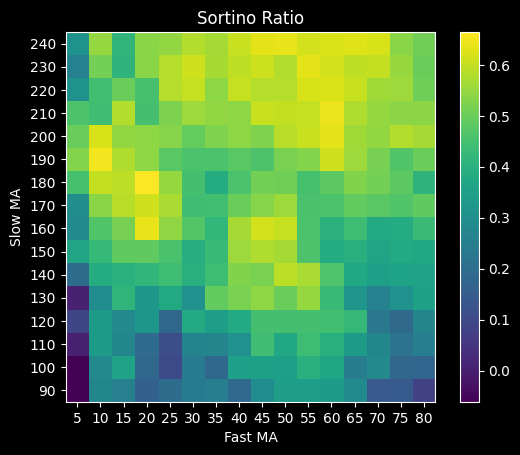

In [ ]:
fig, ax = plt.subplots()
im2 = ax.imshow(hm2, cmap='viridis')
_ = (
    ax.set_xticks(range(len(hm2.columns)), labels=hm2.columns),
    ax.set_yticks(range(len(hm2)), labels=hm2.index),
    ax.set_xlabel('Fast MA'),
    ax.set_ylabel('Slow MA'),
    ax.set_title('Sortino Ratio'),
    ax.figure.colorbar(im2, ax=ax),
)

ax.invert_yaxis()
ax.invert_xaxis()
plt.show()

## Multi-parameter optimization

`Annual Return`     average profit/loss over one-year period (% of starting balance)  
`Max Drawdown`      largest decline in investment value over the course of backtesting   
`Average Drawdown`  average of all individual drawdowns over the course of backtesting  
`Calmar Ratio`      measure of risk-adjusted return by dividing its average annual rate of return by its max drawdown  
`Kelly criterion`   formula for sizing a sequence of bets (trades) by maximizing the long-term expected value



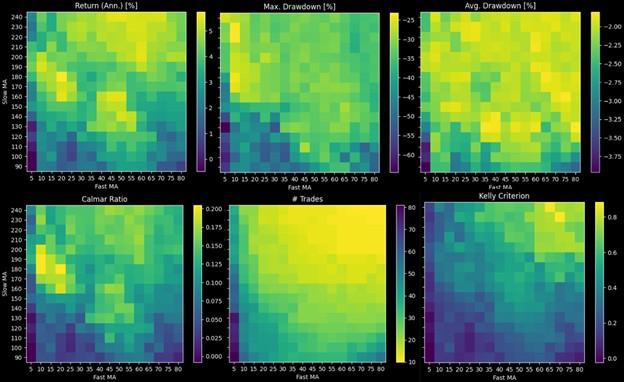

`# Trades` the highest number of trades recorded was 81 (5,90-MAs) and least was 10 (75,230-MAs)    

***Win Rate %** is a very common performance metric, but is **not indicative** of a profitable trading system. Strategies with 80%+ win rates can very easily prove unprofitable over long run and vice versa*

### What is *noise* and what is *real*?

<div class="alert alert-block alert-info">
<b>♾️</b> There is an  ambiguous line between what we can confidenly infer from a backtest and what is simply a reflection of random market movements. Optimizing across performance metrics helps compare robustness of given entry signals
</div>

The heatmaps reveal that parameter combinations with longer periods for both the fast and slow MAs tend to produce more favorable and consistent results across multiple performance metrics. Specifically, entries where the fast MA is set between 45 and 60 periods, and the slow MA is 190 and 220 , consistently show higher performance—indicating these crossover settings are more effective in generating positive returns and managing drawdowns

Still, this confirms only some aspects of the strategy’s robustness. If a strategy underperforms in terms of returns, it is likely to face poor results across other metrics as well, indicating that the relative weakness of that system is often reflected throughout the different metric optimizations-making this exercise less revealing

***

# **Reality check** -  *What does this backtest truly tell us?*

>*"Past performance does not guarantee future results."*
>> No, but it can indicate...

#### Understanding **limitations and biases** linked to backtesting

#### Overfitting
Tailoring parameters specifically to historical data maximizing return while capturing noise instead of signals

### Lookahead Bias
Very common in algorithmic trading - calculated decisions with *tomorrow's* data

#### Market regime changes
MA crossover systems may significanly underperform buy & hold in the future (50,200MAs too slow to catch a selloff especially in uptrends or after spike ups)

## How to improve backtesting



**Use Out-of-Sample Data** - validate performance on a separate period or test on different indexes/assets  

**Walk-Forward Optimization** - re-optimize parameters on recent data 

**Cross-Validation in Time Series** - explore robustness in other time frames 

**Monte Carlo Simulations** - choose parameter and resample or perturb data  

**Trading Assumptions and Costs** - system neglects liquidation constrains, slippage, higher commissions, taxes




## *Are MA crossover systems inherently safer than Buy & Hold?*

<div class="alert alert-block alert-info">
<b>♾️</b> Yes, integral feature of a MA strategy is staying out of bearish markets thus reducing risk compared to buy-and-hold. This holds true for all long-only systems with reasonable MAs (not too near each other) held on trending indexes over long periods of time
</div>

Nevertheless, most crossover strategies **alone** will not perform well during extreme volatility (MAs are too slow to catch news) and on mean reverting assets (possible *false* signals during *sideways markets*)

## Strategy improvements

Assumptions and Simplifications:
The backtest assumes perfect execution with no costs, slippage, or taxes.
It neglects market liquidity constraints or order delays

Altought both backtestesting systems received same entry/exit signals, it is reasonable to assume the performance metrics won't be exactly idenctical. May be worthwhile to examine whether the variance in returns (between two backtests) is caused only by daily compounding (first) or if there is another factor present

System is only tested on one index over 30 years of daily price data

Despite both backtesting methods being limited in their own ways, *backtesting.py* and other trading libraries may appear more frequently in later projects

***

### *CREDITS*



This script is inspired by code originally published by russs123
 * Original work is licensed under the MIT License; Copyright (c) 2024 russs123
 * [See original code](https://github.com/russs123/moving_average/blob/main/README.md) *full license attached beneath*



MIT License

Copyright (c) 2024 russs123

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.